<a href="https://colab.research.google.com/github/cjatian/ATIAN_CPE018-CPE31S2/blob/main/Activity_9_ORB_Feature_Detection_and_Feature_Matching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 018
Code Title: | Emerging Technologies in CpE 1 - Fundamentals of Computer Vision
1st Semester | AY 2023-2024
<hr> | <hr>
<u>**ACTIVITY NO.** | **TITLE**
**Name** | LastName, FirstName
**Section** | CPE31Sx
**Date Performed**: |
**Date Submitted**: |
**Instructor**: | Dr. Jonathan V. Taylar / Engr. Verlyn V. Nojor / Engr. Roman M. Richard

<hr>

## 1. Objectives

This activity aims to enable students to perform feature detection and feature matching using Oriented FAST and Rotated BRIEF (ORB) algorithm with OpenCV.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Demonstrate the use of oriented FAST and rotated BRIEF algorithm implemented through the use of OpenCV, debugging and modification.
* Evaluate feature detection using Oriented FAST and rotated BRIEF algorithm on images to detect important features.

## 3. Procedures and Outputs

**BEFORE YOU PROCEED WITH THIS SECTION: PLEASE MAKE SURE YOU HAVE READ THE CONTENTS OF THE MODULE REGARDING BRIEF AND FAST**

The team that created ORB (Ethan Rublee, Vincent Rabaud, Kurt Konolige, and Gary R. Bradski) chose to build it on FAST and BRIEF because these two algorithms are fast and efficient.

In their paper, the authors of ORB set out to achieve the following:

* Add a fast and accurate way to determine the orientation of FAST keypoints.
* Find a way to efficiently compute BRIEF features that are also rotation-invariant.
Analyze the variance and correlation of oriented BRIEF features.
* Develop a learning method to decorrelate BRIEF features under rotational invariance, which would improve performance in nearest-neighbor applications.
* In other words, the ORB team wanted to make feature detection and matching faster and more accurate, especially in situations where the training image and query image have different rotations.

The main points of the text are clear, even if you don't understand all of the technical jargon. ORB is a fast and efficient algorithm for feature detection and matching, and it is especially good at matching features that have different rotations.

I bet you are eager to start coding with ORB, so let's move on to some code examples.

Parts of this activity contribute towards the attainment of `ILO1: Demonstrate the use of oriented FAST and rotated BRIEF algorithm implemented through the use of OpenCV, debugging and modification.`

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
from matplotlib import pyplot as plt
import os
from google.colab import drive

drive_path = '/content/drive/MyDrive/CPE018-CPE31S2/'

image1 = cv2.imread(os.path.join(drive_path, 'armybomb.jpg'), cv2.IMREAD_GRAYSCALE)
image2 = cv2.imread(os.path.join(drive_path, 'btslogo.jpg'), cv2.IMREAD_GRAYSCALE)

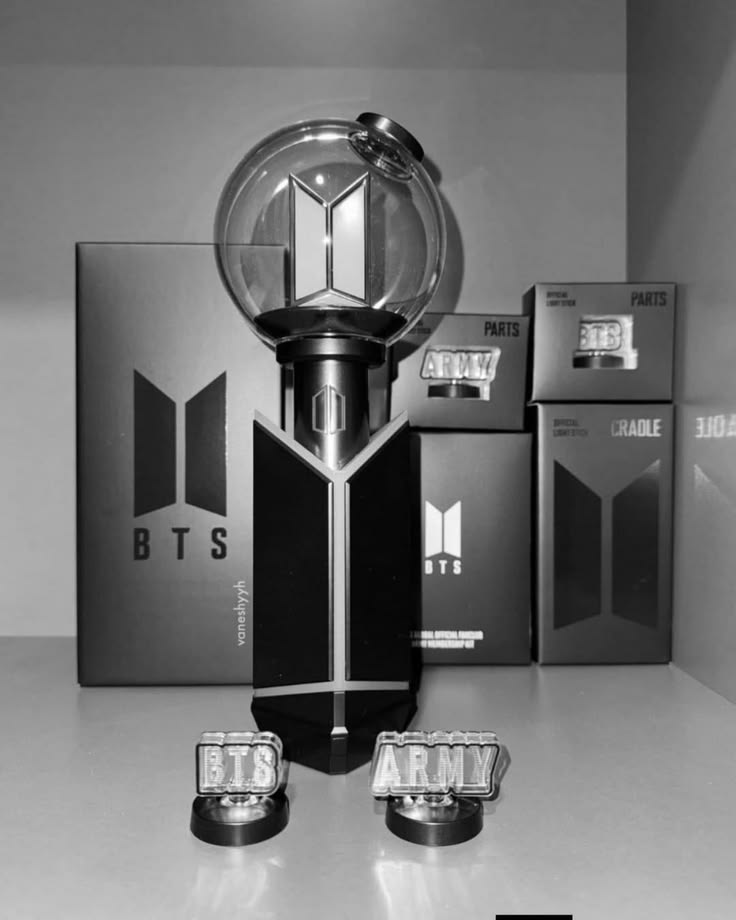

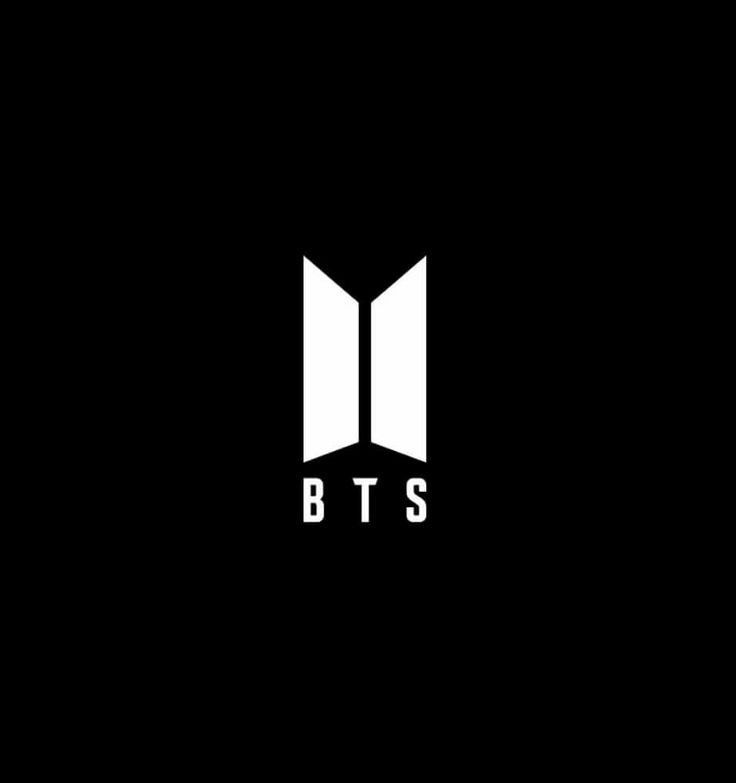

In [11]:
# Preview the 2 images
cv2_imshow(image1)
cv2_imshow(image2)

In [13]:
# Create the ORB feature and detector descriptor
orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(image1,None) # Reference image
kp2, des2 = orb.detectAndCompute(image2,None)

**Analysis: Explain the purpose of detector and descriptor and why they're used here.**

- The detector and descriptor serve two distinct but complementary purposes in feature matching. The detector, implemented through ORB_create, identifies the keypoints in the image where features are present, focusing on corners and blob-like structures that are distinctive. The descriptor then creates a unique numerical representation or the fingerprint for each keypoint that describes the local image pattern around it. The detector tells us where the interesting points are, while the descriptor tells us what those points look like. They work together because without the detector, we wouldn't know where to look, and without the descriptor, we couldn't compare features between images.

In [14]:
"""
The BFMatcher is a simple but effective algorithm for feature matching.
It works by comparing each feature in one image to every feature in the other
image and returning the pair of features with the smallest distance.
"""

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

"""
The match() method takes two arguments:
  - the descriptors of the features in the first image
  - the descriptors of the features in the second image.

It returns a list of matches, where each match is a pair of feature indices,
one from each image.
"""

matches = bf.match(des1,des2)


In [15]:

"""
Next, we sort the matches in order of their distance.
This ensures that the best matches are returned first.
"""
sorted_matches = sorted(matches, key = lambda x:x.distance)

"""
Then, we draw the top 40 matches between the two images.
The drawMatches() method takes two arguments: the two images, and a list of matches.
It draws lines between the corresponding keypoints in the two images.
"""

image3 = cv2.drawMatches(image1,kp1,image2,kp2, sorted_matches[:40],image2,flags=2)

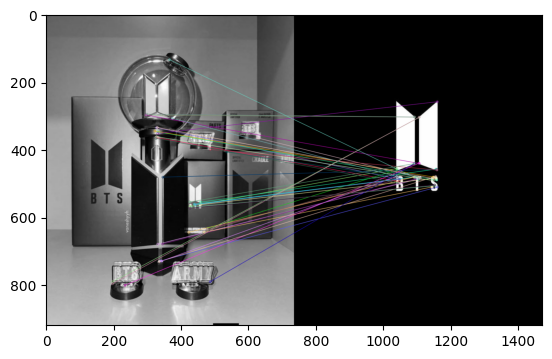

(<matplotlib.image.AxesImage at 0x79bbdcbda1b0>, None)

In [16]:
from matplotlib import pyplot as plt

plt.imshow(image3),plt.show()

**Question**
Provide an analysis on the way the ORB algorithm works here, are the results correct? What can/should be improved?

- The ORB algorithm performed decently in matching the PlayStation logo between the two images. The matches show that ORB successfully identified keypoints on the logo in both images and connected them with lines. However, looking at the result, I noticed that not all matches were perfectly accurate. Some lines connected completely different parts of the logo, which means those were false matches. The algorithm also missed some obvious matching points because the lighting conditions between the two images were different, and the logo size varied significantly. What could be improved from it is to adjust the ORB parameters like the number of features to detect or the scale factor between pyramid levels. The default parameters work for general cases, but for specific logo matching, tuning these values could yield better results. Using a more aggressive distance threshold for matches would also reduce false positives. Additionally, applying a ratio test, similar to what Lowe's paper suggests for SIFT, could filter out ambiguous matches and keep only the most confident ones.

## 4. Supplementary Activity

**ILO2: Evaluate feature detection using Oriented FAST and rotated BRIEF algorithm on images to detect important features.**

Perform the following tasks:
1. Find 2 images of brand logos on the internet.
2. Find 5 product images containing one logo each.
3. Test the ORB algorithm to detect and match the features on the images. Document the testing.
4. Evaluate the algorithm's performance, was it able to detect the important features? Was it also reliable in not finding the logos that are not on the provided images?
5. Provide an analysis: Why did it work, or otherwise? What would you change to improve the results if you could?

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


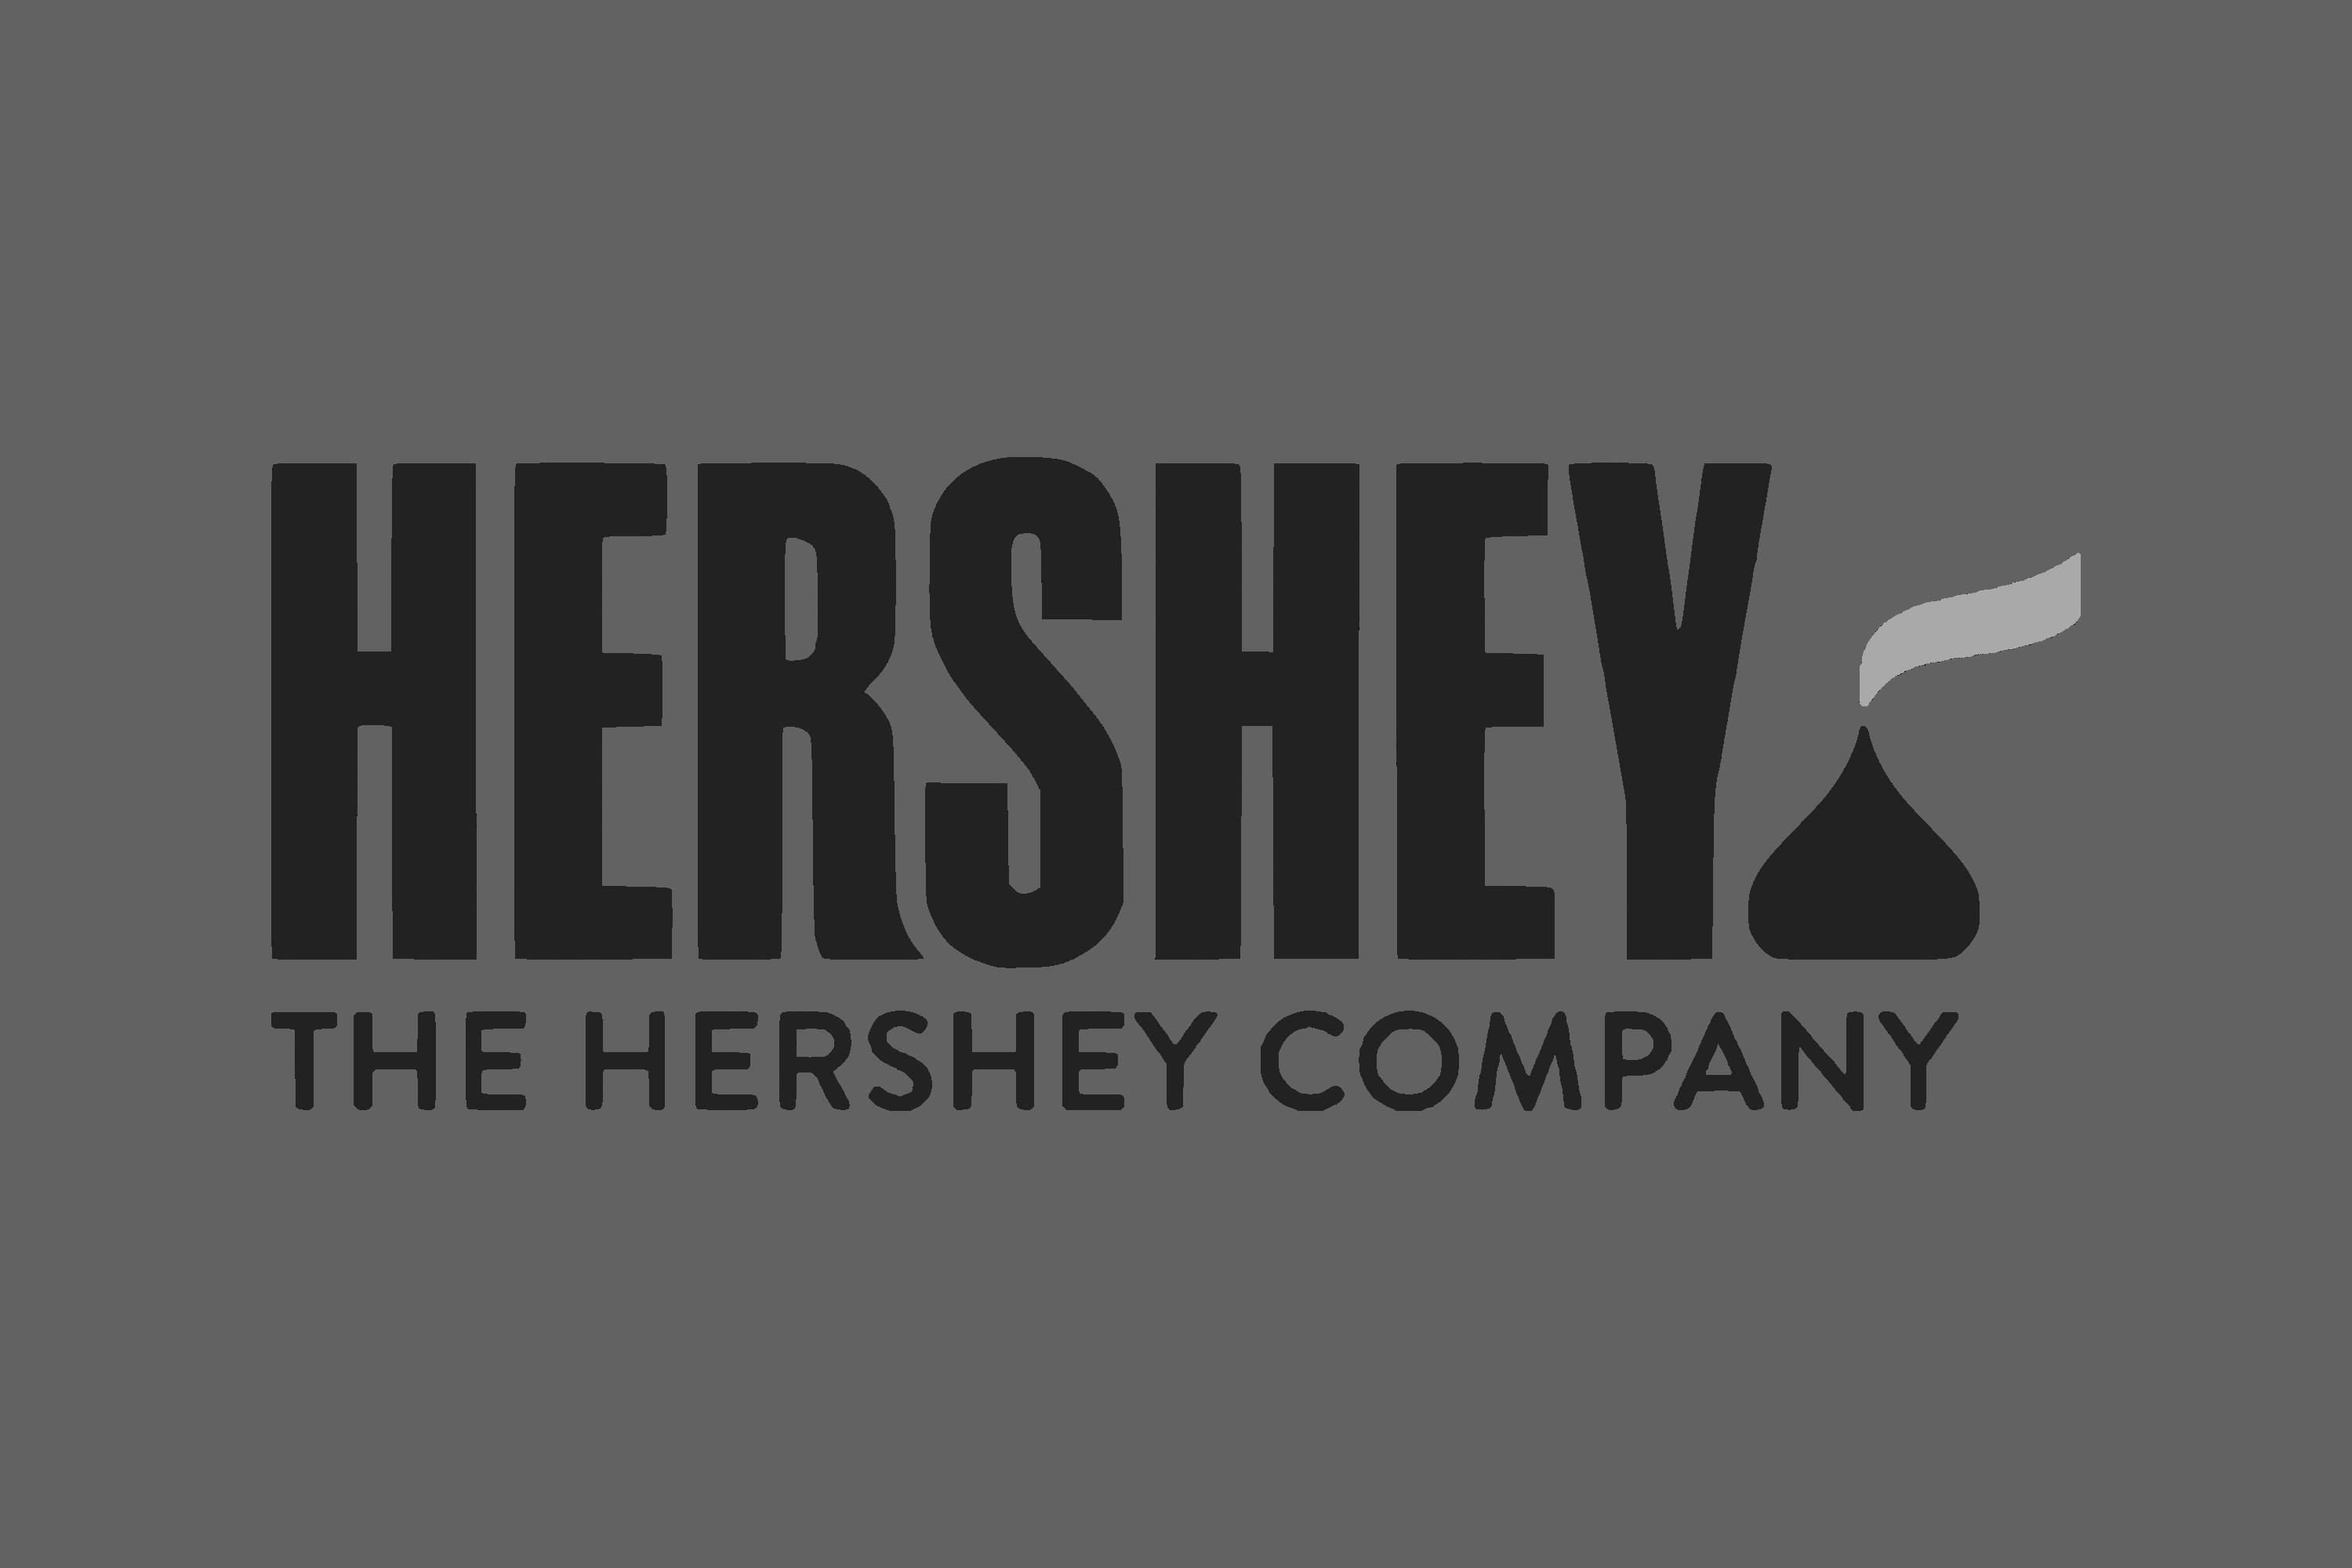

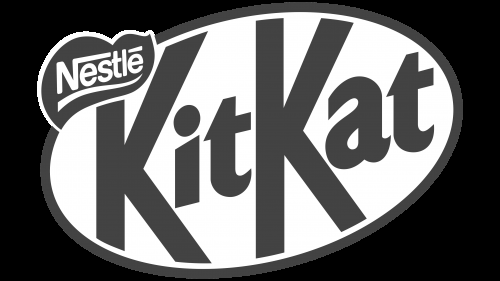

In [24]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
from matplotlib import pyplot as plt
import os

drive_path = '/content/drive/MyDrive/CPE018-CPE31S2/'

hershey_logo = cv2.imread(os.path.join(drive_path, 'hersheylogo.jpg'), cv2.IMREAD_GRAYSCALE)
kitkat_logo = cv2.imread(os.path.join(drive_path, 'kitkatlogo.jpg'), cv2.IMREAD_GRAYSCALE)

cv2_imshow(hershey_logo)
cv2_imshow(kitkat_logo)


Total product images: 10

Previewing Product Images:

Product 1: Hershey's - hersheycm


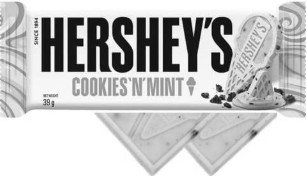


Product 2: Hershey's - hersheyfw


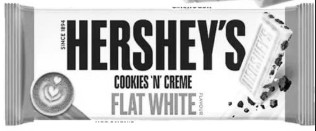


Product 3: Hershey's - hersheysc


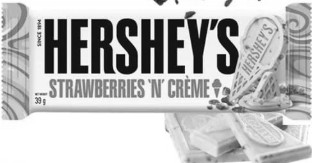


Product 4: Hershey's - hersheymc


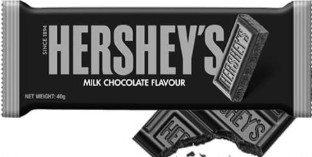


Product 5: Hershey's - hersheycc


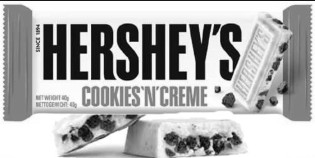


Product 6: KitKat - kitkatsc


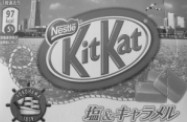


Product 7: KitKat - kitkatav


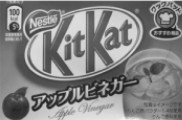


Product 8: KitKat - kitkatsp


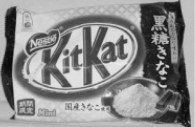


Product 9: KitKat - kitkatbp


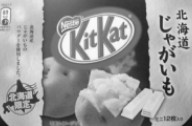


Product 10: KitKat - kitkatw


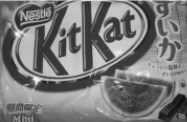

In [28]:
hershey_products = ['hersheycm.jpg', 'hersheyfw.jpg', 'hersheysc.jpg', 'hersheymc.jpg', 'hersheycc.jpg']
kitkat_products = ['kitkatsc.jpg', 'kitkatav.jpg', 'kitkatsp.jpg', 'kitkatbp.jpg', 'kitkatw.jpg']

product_images = []
product_names = []

for prod in hershey_products:
    img = cv2.imread(os.path.join(drive_path, prod), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        product_images.append(img)
        product_names.append(f"Hershey's - {prod.replace('.jpg', '')}")

for prod in kitkat_products:
    img = cv2.imread(os.path.join(drive_path, prod), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        product_images.append(img)
        product_names.append(f"KitKat - {prod.replace('.jpg', '')}")

print(f"\nTotal product images: {len(product_images)}")
print("\nPreviewing Product Images:")
for i in range(min(10, len(product_images))):
    print(f"\nProduct {i+1}: {product_names[i]}")
    cv2_imshow(product_images[i])

Hershey's Logo keypoints: 500
KitKat Logo keypoints: 500
Hershey's Logo - Matches: 37, Best distance: 46.0
KitKat Logo - Matches: 131, Best distance: 42.0

Detected: KitKat


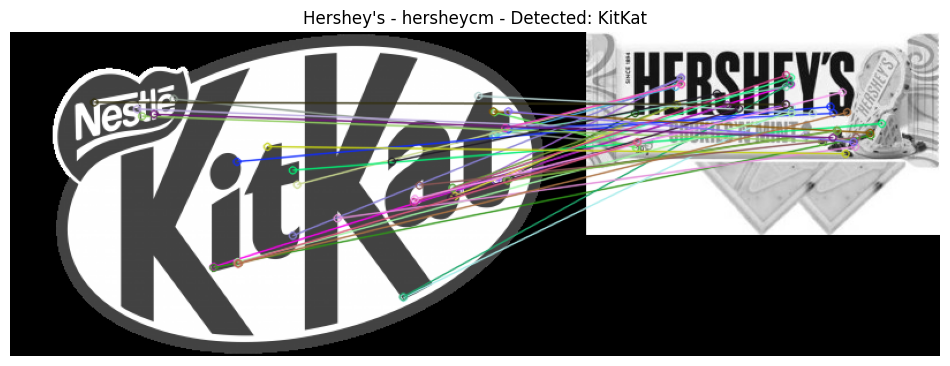

Hershey's Logo - Matches: 36, Best distance: 46.0
KitKat Logo - Matches: 121, Best distance: 45.0

Detected: KitKat


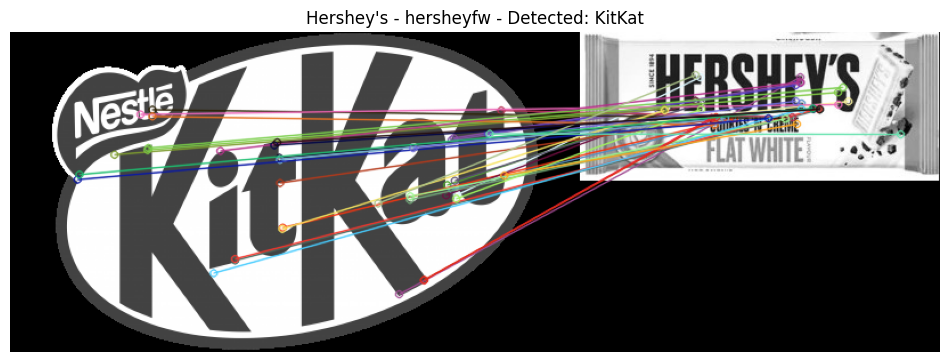

Hershey's Logo - Matches: 37, Best distance: 44.0
KitKat Logo - Matches: 129, Best distance: 38.0

Detected: KitKat


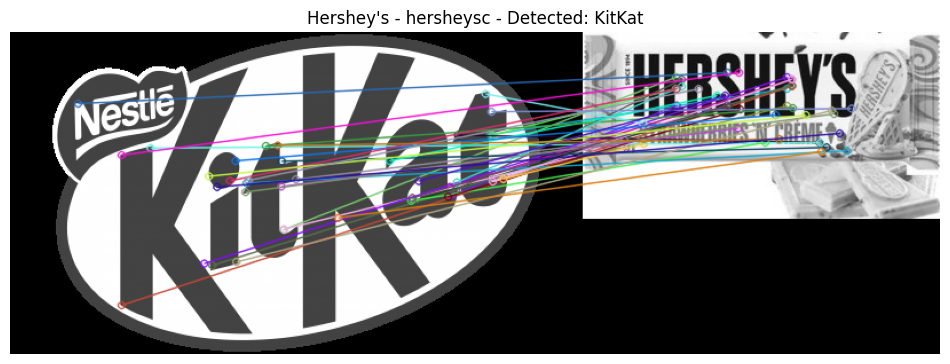

Hershey's Logo - Matches: 31, Best distance: 28.0
KitKat Logo - Matches: 123, Best distance: 46.0

Detected: KitKat


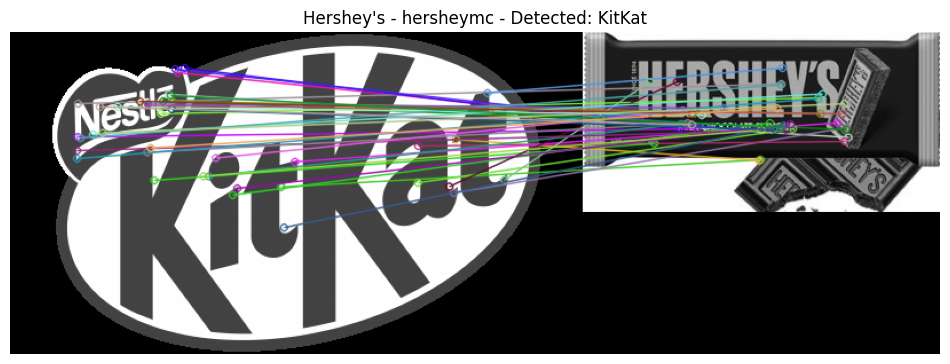

Hershey's Logo - Matches: 36, Best distance: 38.0
KitKat Logo - Matches: 118, Best distance: 41.0

Detected: KitKat


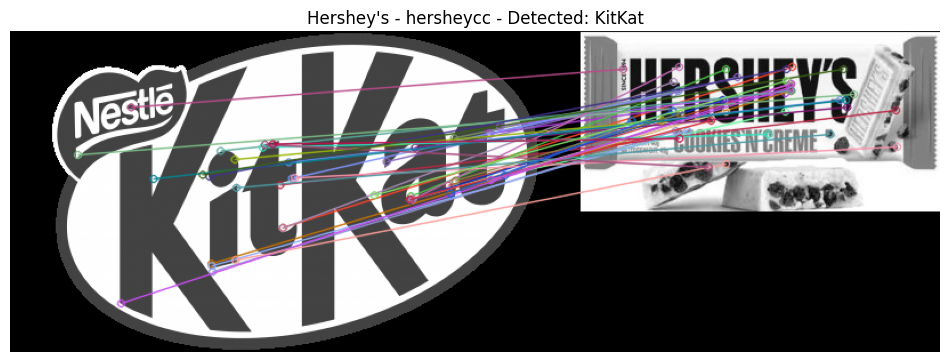

Hershey's Logo - Matches: 40, Best distance: 56.0
KitKat Logo - Matches: 101, Best distance: 21.0

Detected: KitKat


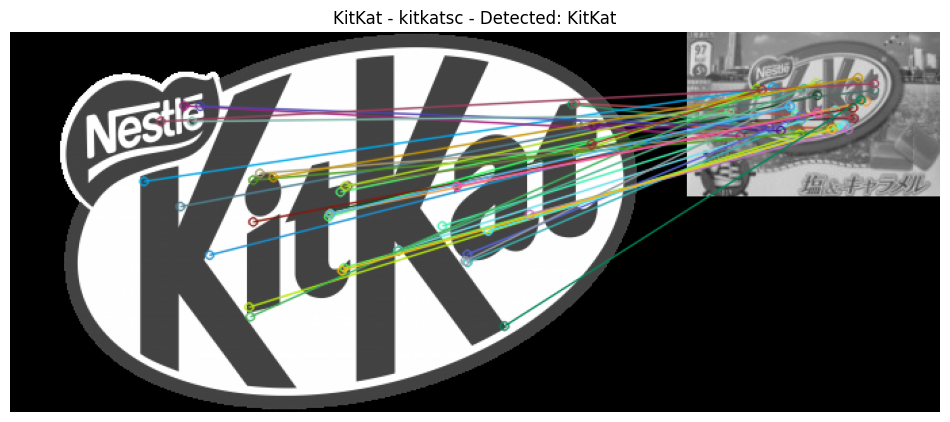

Hershey's Logo - Matches: 32, Best distance: 47.0
KitKat Logo - Matches: 88, Best distance: 31.0

Detected: KitKat


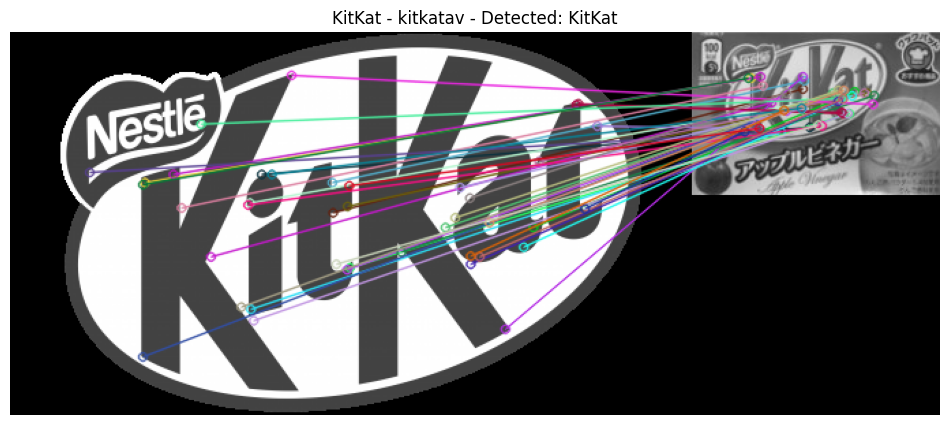

Hershey's Logo - Matches: 44, Best distance: 50.0
KitKat Logo - Matches: 112, Best distance: 40.0

Detected: KitKat


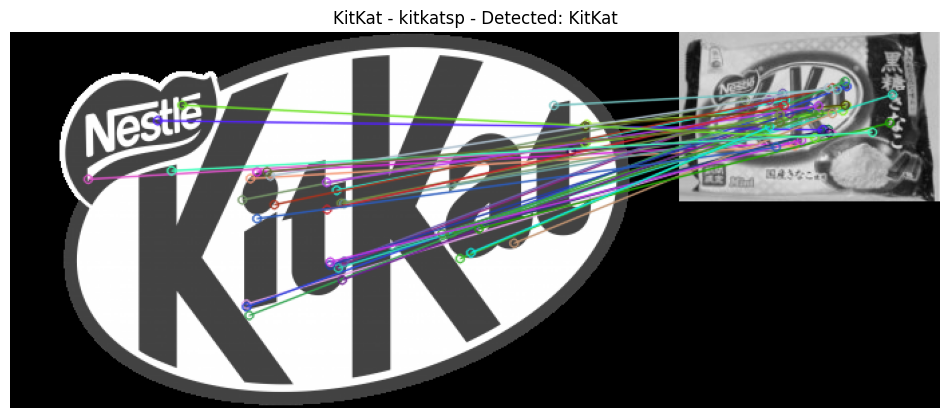

Hershey's Logo - Matches: 36, Best distance: 36.0
KitKat Logo - Matches: 86, Best distance: 40.0

Detected: KitKat


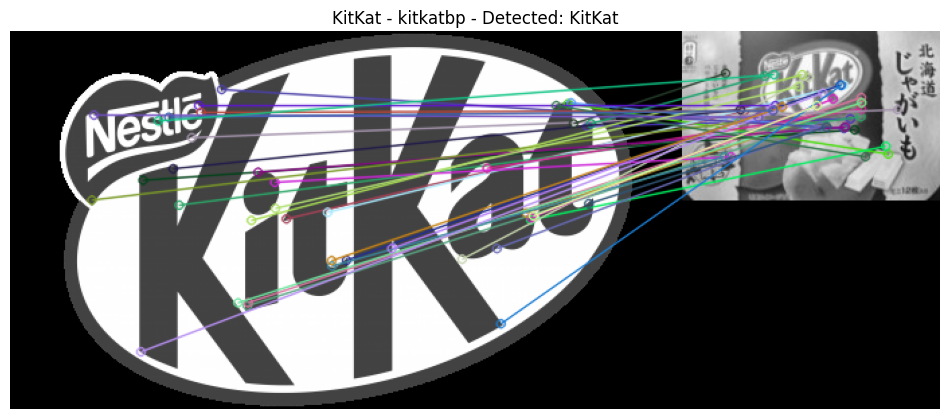

Hershey's Logo - Matches: 36, Best distance: 40.0
KitKat Logo - Matches: 98, Best distance: 23.0

Detected: KitKat


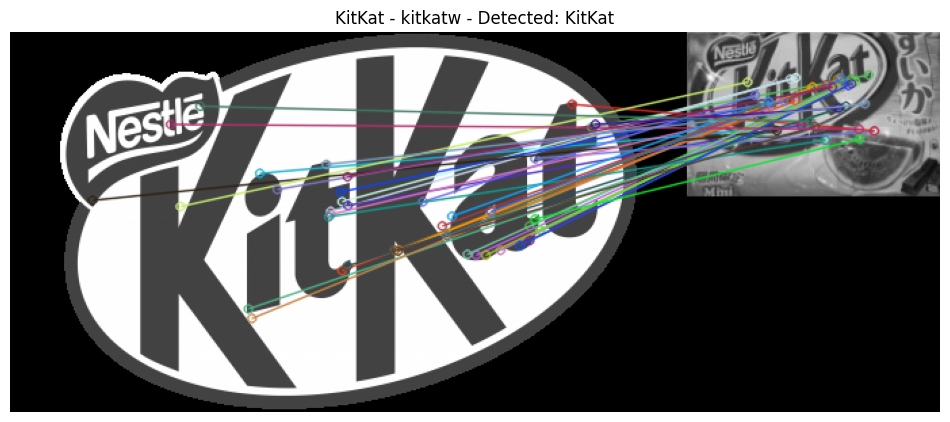

In [33]:

orb = cv2.ORB_create()
kp_logo1, des_logo1 = orb.detectAndCompute(hershey_logo, None)
kp_logo2, des_logo2 = orb.detectAndCompute(kitkat_logo, None)

print(f"Hershey's Logo keypoints: {len(kp_logo1)}")
print(f"KitKat Logo keypoints: {len(kp_logo2)}")

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

def test_matching(logo_img, logo_kp, logo_des, product_img, product_name, logo_name):
    kp_product, des_product = orb.detectAndCompute(product_img, None)

    if logo_des is None or des_product is None:
        return None, 0, 0

    matches = bf.match(logo_des, des_product)
    matches = sorted(matches, key=lambda x: x.distance)
    result_img = cv2.drawMatches(logo_img, logo_kp, product_img, kp_product,
                                  matches[:40], None,
                                  flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    return result_img, len(matches), matches[0].distance if matches else 0

all_results = []

for i, (product_img, product_name) in enumerate(zip(product_images, product_names)):
    result1, matches1, best_dist1 = test_matching(hershey_logo, kp_logo1, des_logo1,
                                                   product_img, product_name, "Hershey's")
    result2, matches2, best_dist2 = test_matching(kitkat_logo, kp_logo2, des_logo2,
                                                   product_img, product_name, "KitKat")

    print(f"Hershey's Logo - Matches: {matches1}, Best distance: {best_dist1:.1f}")
    print(f"KitKat Logo - Matches: {matches2}, Best distance: {best_dist2:.1f}")

    detected = "None"
    if matches1 > matches2 and matches1 > 10:
        detected = "Hershey's"
        best_result = result1
    elif matches2 > matches1 and matches2 > 10:
        detected = "KitKat"
        best_result = result2
    else:
        best_result = None

    all_results.append({
        'product': product_name,
        'detected': detected,
        'matches_hershey': matches1,
        'matches_kitkat': matches2,
        'result': best_result
    })

    print(f"\nDetected: {detected}")

    if best_result is not None:
        plt.figure(figsize=(12, 6))
        plt.imshow(best_result)
        plt.title(f'{product_name} - Detected: {detected}')
        plt.axis('off')
        plt.show()

## 5. Summary, Conclusions and Lessons Learned

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*